In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("online_retail_II.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
df[df['Customer ID'].isna()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [8]:
df=df.dropna(subset=['Customer ID','Description'])

In [9]:
df[['Customer ID','Description']].isna().sum()

Customer ID    0
Description    0
dtype: int64

In [10]:
df.shape

(824364, 8)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


In [12]:
sum(df['Quantity']<=0)

18744

In [13]:
sum(df['Price']<=0)

71

In [14]:
df=df[(df['Quantity']>0) & (df['Price']>0)]

In [15]:
df.shape

(805549, 8)

In [16]:
sum(df['Quantity']<=0)

0

In [17]:
sum(df['Price']<=0)

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  object 
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB


In [19]:
df['InvoiceDate'].head()

0    2009-12-01 07:45:00
1    2009-12-01 07:45:00
2    2009-12-01 07:45:00
3    2009-12-01 07:45:00
4    2009-12-01 07:45:00
Name: InvoiceDate, dtype: object

In [20]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [21]:
df['InvoiceDate']=df['InvoiceDate'].dt.date
df["InvoiceDate"]

0          2009-12-01
1          2009-12-01
2          2009-12-01
3          2009-12-01
4          2009-12-01
              ...    
1067366    2011-12-09
1067367    2011-12-09
1067368    2011-12-09
1067369    2011-12-09
1067370    2011-12-09
Name: InvoiceDate, Length: 805549, dtype: object

In [22]:
df['Analysis_Date']=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [23]:
df['Analysis_Date'].head()

0    2011-12-10
1    2011-12-10
2    2011-12-10
3    2011-12-10
4    2011-12-10
Name: Analysis_Date, dtype: object

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Invoice        805549 non-null  object 
 1   StockCode      805549 non-null  object 
 2   Description    805549 non-null  object 
 3   Quantity       805549 non-null  int64  
 4   InvoiceDate    805549 non-null  object 
 5   Price          805549 non-null  float64
 6   Customer ID    805549 non-null  float64
 7   Country        805549 non-null  object 
 8   Analysis_Date  805549 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 61.5+ MB


In [25]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Analysis_Date'] = pd.to_datetime(df['Analysis_Date'])

In [26]:
df['Recency']=(df['Analysis_Date']-df['InvoiceDate']).dt.days
df['Recency'].head()

0    739
1    739
2    739
3    739
4    739
Name: Recency, dtype: int64

In [27]:
df['total_amount']=df['Quantity']*df['Price']
df['total_amount'].head()

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
Name: total_amount, dtype: float64

In [28]:
df=df.rename(columns={
    'Customer ID':'Customer_ID'
})
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country', 'Analysis_Date', 'Recency',
       'total_amount'],
      dtype='object')

In [29]:
df['Invoice'].nunique()

36969

In [30]:
df_customer_purchase_details=df.groupby('Customer_ID').agg(
    latest_date=('InvoiceDate','max'),
    frequency=('Invoice','nunique'),
    montery=('total_amount','sum')
).reset_index()

In [31]:
df_customer_purchase_details

,Customer_ID,latest_date,frequency,montery
0,12346.0,2011-01-18,12,77556.46
1,12347.0,2011-12-07,8,5633.32
2,12348.0,2011-09-25,5,2019.40
3,12349.0,2011-11-21,4,4428.69
4,12350.0,2011-02-02,1,334.40
...,...,...,...,...
5873,18283.0,2011-12-06,22,2736.65
5874,18284.0,2010-10-04,1,461.68
5875,18285.0,2010-02-17,1,427.00
5876,18286.0,2010-08-20,2,1296.43


In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df_customer_purchase_details = df.groupby('Customer_ID').agg(
    latest_date=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),
    monetary=('total_amount', 'sum')
).reset_index()

df_customer_purchase_details['recency'] = (
    analysis_date - df_customer_purchase_details['latest_date']
).dt.days

In [33]:
df_customer_purchase_details.head(10)

,Customer_ID,latest_date,frequency,monetary,recency
0,12346.0,2011-01-18,12,77556.46,326
1,12347.0,2011-12-07,8,5633.32,3
2,12348.0,2011-09-25,5,2019.40,76
3,12349.0,2011-11-21,4,4428.69,19
4,12350.0,2011-02-02,1,334.40,311
5,12351.0,2010-11-29,1,300.93,376
6,12352.0,2011-11-03,10,2849.84,37
7,12353.0,2011-05-19,2,406.76,205
8,12354.0,2011-04-21,1,1079.40,233
9,12355.0,2011-05-09,2,947.61,215


In [34]:
df_customer_purchase_details.drop('latest_date',axis=1,inplace=True)

In [35]:
df_customer_purchase_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer_ID  5878 non-null   float64
 1   frequency    5878 non-null   int64  
 2   monetary     5878 non-null   float64
 3   recency      5878 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [36]:
df_customer_purchase_details.describe()

,Customer_ID,frequency,monetary,recency
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,6.289384,3018.616737,201.866791
std,1715.572666,13.009406,14737.731040,209.353961
min,12346.000000,1.000000,2.950000,1.000000
25%,13833.250000,1.000000,348.762500,26.000000
50%,15314.500000,3.000000,898.915000,96.000000
75%,16797.750000,7.000000,2307.090000,380.000000
max,18287.000000,398.000000,608821.650000,739.000000


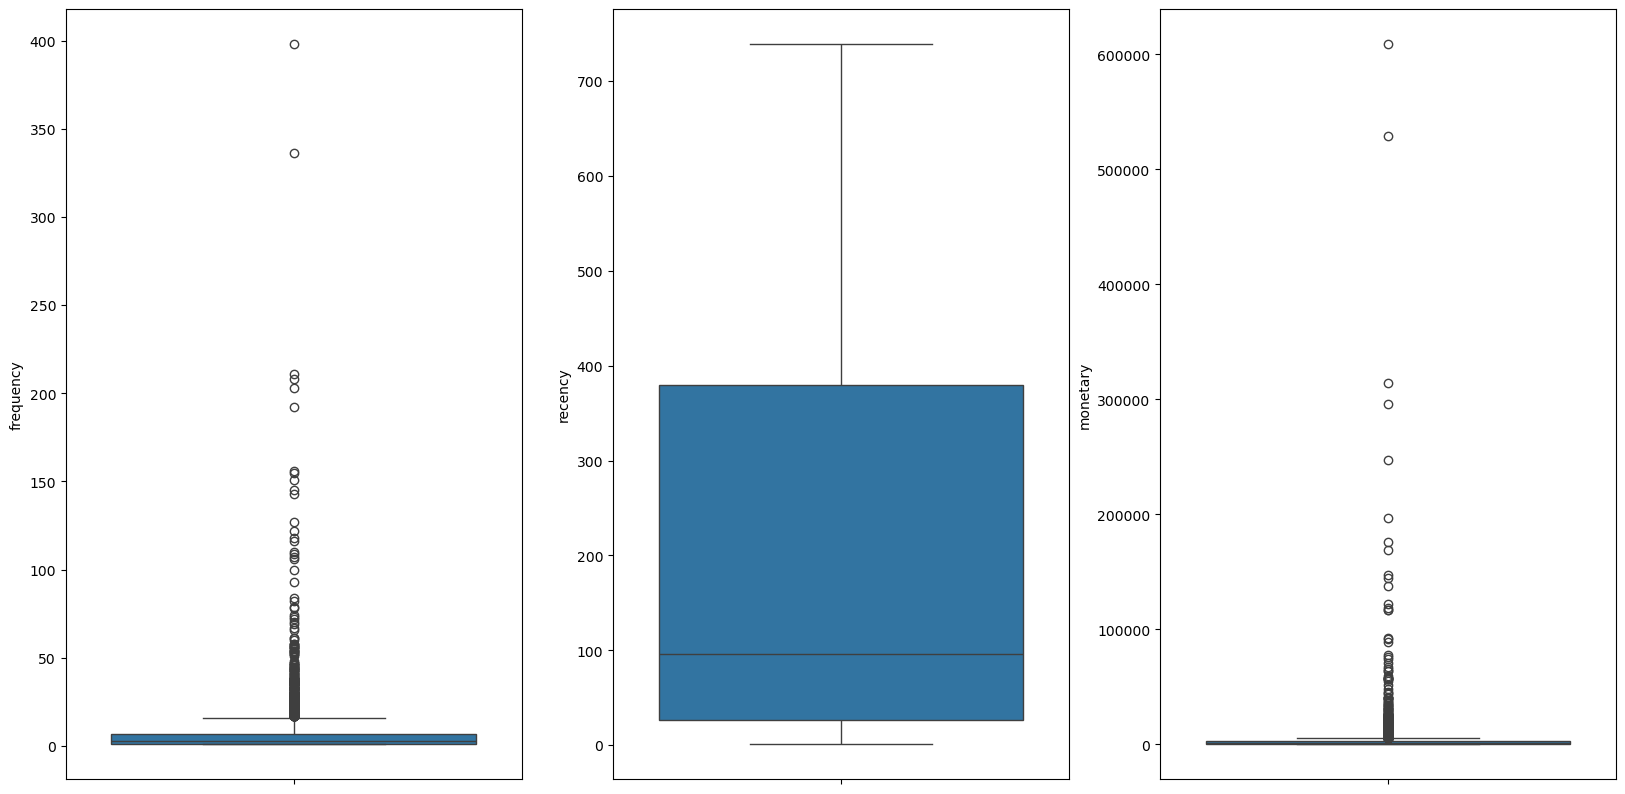

In [37]:
plt.figure(figsize=(20,10))
plt.subplot(1,3,1)
sns.boxplot(data=df_customer_purchase_details,y="frequency")
plt.subplot(1,3,2)
sns.boxplot(data=df_customer_purchase_details,y="recency")
plt.subplot(1,3,3)
sns.boxplot(data=df_customer_purchase_details,y="monetary")
plt.show()

In [38]:
X=df_customer_purchase_details[['recency','frequency','monetary']]
X.columns

Index(['recency', 'frequency', 'monetary'], dtype='object')

In [39]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
X_scaled=scaler.fit_transform(X)

X_scaled[:11]

array([[ 6.49717514e-01,  1.50000000e+00,  3.91443949e+01],
       [-2.62711864e-01,  8.33333333e-01,  2.41757571e+00],
       [-5.64971751e-02,  3.33333333e-01,  5.72164258e-01],
       [-2.17514124e-01,  1.66666667e-01,  1.80244367e+00],
       [ 6.07344633e-01, -3.33333333e-01, -2.88263837e-01],
       [ 7.90960452e-01, -3.33333333e-01, -3.05354952e-01],
       [-1.66666667e-01,  1.16666667e+00,  9.96219989e-01],
       [ 3.07909605e-01, -1.66666667e-01, -2.51313940e-01],
       [ 3.87005650e-01, -3.33333333e-01,  9.21628277e-02],
       [ 3.36158192e-01, -1.66666667e-01,  2.48656060e-02],
       [-2.06214689e-01,  5.00000000e-01,  2.79563301e+00]])

In [40]:
cols_median_iqr=pd.DataFrame({
    'Columns':X.columns,
    'Median':scaler.center_,
    'IQR':scaler.scale_
})

cols_median_iqr

,Columns,Median,IQR
0,recency,96.000,354.0000
1,frequency,3.000,6.0000
2,monetary,898.915,1958.3275


In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score

inertia_values=[]
silhouette_score_values=[]

for i in range(2,11):
    model=KMeans(
        n_clusters=i,
        init='k-means++',
        n_init='auto',
        max_iter=300,
        tol=0.0001,
        random_state=94
    )
    
    labels=model.fit_predict(X_scaled)
    
    inertia_values.append(model.inertia_)
    silhouette_score_values.append(silhouette_score(X_scaled,labels))

In [46]:
k_inertia_silhoutte=pd.DataFrame({
    'K-Range':range(2,11),
    'Inertia':inertia_values,
    "Silhouette_Score":silhouette_score_values
})

k_inertia_silhoutte

,K-Range,Inertia,Silhouette_Score
0,2,155439.630061,0.976625
1,3,84067.672396,0.966396
2,4,52771.415901,0.877863
3,5,38088.775702,0.821544
4,6,28982.556978,0.775061
5,7,23258.989842,0.730118
6,8,19147.556681,0.559184
7,9,17212.047523,0.475484
8,10,15322.197088,0.444270


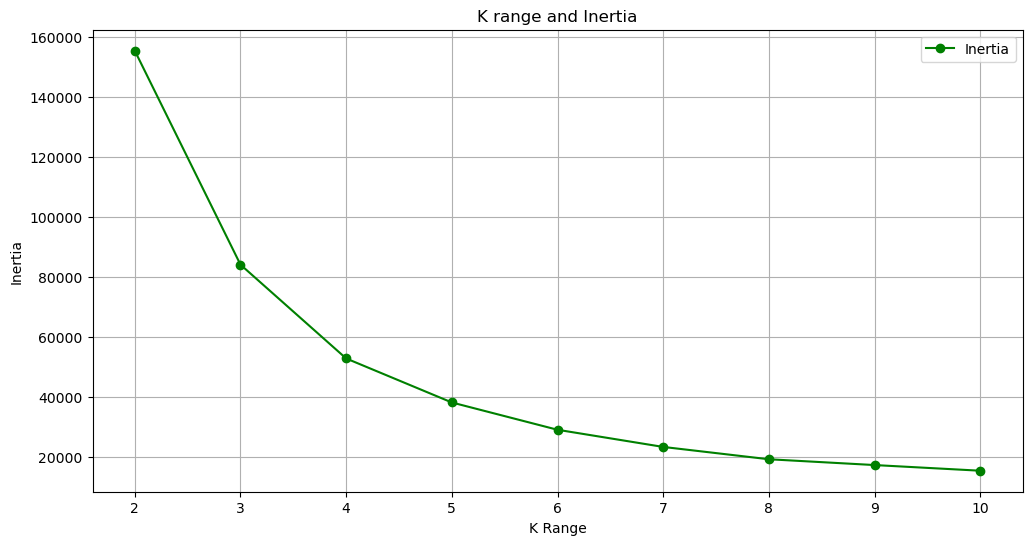

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    range(2,11),
    inertia_values,
    marker='o',
    linestyle='-',
    color='g',
    label='Inertia'
)

plt.title("K range and Inertia")
plt.xlabel("K Range")
plt.ylabel("Inertia")
plt.legend()

plt.grid(True)
plt.show()

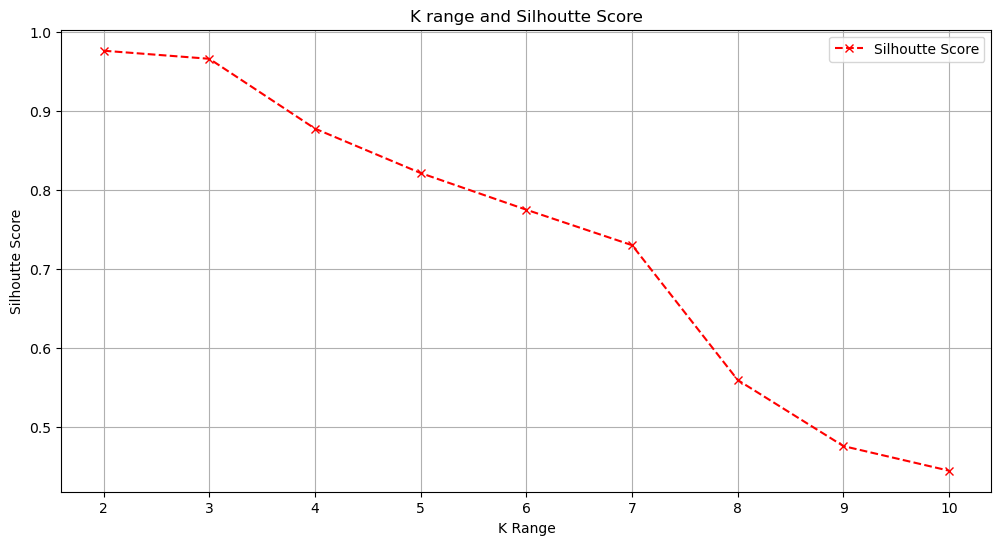

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    range(2,11),
    silhouette_score_values,
    marker='x',
    linestyle='--',
    color='r',
    label='Silhoutte Score'
)

plt.title("K range and Silhoutte Score")
plt.xlabel("K Range")
plt.ylabel("Silhoutte Score")
plt.legend()

plt.grid(True)
plt.show()

In [51]:
best_model=KMeans(
    n_clusters=3,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    random_state=94
)

df_customer_purchase_details['Cluster']=best_model.fit_predict(X_scaled)
df_customer_purchase_details['Cluster'].value_counts()

Cluster
0    5857
1      19
2       2
Name: count, dtype: int64

In [52]:
df_customer_purchase_details.groupby('Cluster')[['frequency', 'monetary', 'recency']].agg(['mean', 'median', 'min', 'max'])

frequency                        monetary                         \
               mean median  min  max           mean      median        min   
Cluster                                                                      
0          5.834898    3.0    1  192    2361.144217     891.340       2.95   
1        131.473684  110.0    2  398  146146.491053  122209.140   56599.39   
2        148.000000  148.0  145  151  568712.085000  568712.085  528602.52   

                       recency                  
               max        mean median min  max  
Cluster                                         
0         77556.46  202.564111   97.0   1  739  
1        313946.37    8.000000    4.0   1   39  
2        608821.65    1.500000    1.5   1    2